In [1]:
import os

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import USPS
from torchvision.transforms import v2
from torchvision.utils import make_grid
from torchinfo import summary

import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE, torch.cuda.device_count()

('cuda', 1)

In [3]:
cwd = os.getcwd()
os.chdir("..")

transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

train_data = USPS(
    root="data",
    train=True,
    download=False,
    transform=transform,
)
test_data = USPS(
    root="data",
    train=False,
    download=False,
    transform=transform,
)

print(len(train_data))
print(len(test_data))
print(f"Shape : {train_data.data.shape}")

os.chdir(cwd)
os.getcwd()

7291
2007
Shape : (7291, 16, 16)


'c:\\Users\\USER\\ipnyb files\\Autoencoders'

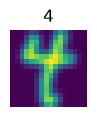

In [4]:
plt.figure(figsize=(1, 1))
plt.imshow(train_data.data[16])
plt.title(train_data.targets[16])
plt.axis("off")
plt.show()

In [5]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

## Network Architecture


In [6]:
from typing import Any


class VAE(nn.Module):
    def __init__(self, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.encoder = nn.Sequential(
            OrderedDict(
                [
                    ("linr1", nn.Linear(in_features=16 * 16, out_features=128)),
                    ("relu1", nn.ReLU()),
                    ("linr2", nn.Linear(in_features=128, out_features=64)),
                    ("relu2", nn.ReLU()),
                    ("linr3", nn.Linear(in_features=64, out_features=64)),
                ]
            )
        )

        self._mu = nn.Linear(in_features=64, out_features=30)
        self._logvar = nn.Linear(in_features=64, out_features=30)

        self.decoder = nn.Sequential(
            OrderedDict(
                [
                    ("linr3", nn.Linear(in_features=30, out_features=64)),
                    ("relu3", nn.ReLU()),
                    ("linr2", nn.Linear(in_features=64, out_features=128)),
                    ("relu2", nn.ReLU()),
                    ("linr1", nn.Linear(in_features=128, out_features=16 * 16)),
                    ("sigmoid1", nn.Sigmoid()),
                ]
            )
        )

    def reparametrization(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        sampling = mu + (std * eps)
        return sampling

    def forward(self, x):
        x = self.encoder(x.reshape(x.shape[0], -1))

        mu = self._mu(x)
        logvar = self._logvar(x)

        x = self.reparametrization(mu, logvar)
        return self.decoder(x), mu, logvar

In [7]:
model = VAE().to(DEVICE)
summary(model, input_size=(32, 1, 16, 16), device=DEVICE)

Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [32, 256]                 --
├─Sequential: 1-1                        [32, 64]                  --
│    └─Linear: 2-1                       [32, 128]                 32,896
│    └─ReLU: 2-2                         [32, 128]                 --
│    └─Linear: 2-3                       [32, 64]                  8,256
│    └─ReLU: 2-4                         [32, 64]                  --
│    └─Linear: 2-5                       [32, 64]                  4,160
├─Linear: 1-2                            [32, 30]                  1,950
├─Linear: 1-3                            [32, 30]                  1,950
├─Sequential: 1-4                        [32, 256]                 --
│    └─Linear: 2-6                       [32, 64]                  1,984
│    └─ReLU: 2-7                         [32, 64]                  --
│    └─Linear: 2-8                       [32, 128]                

## Train and Test Functions


In [8]:
def train_vae(dataloader, model, optimizer, loss_fn, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()
        X, y = X.to(device), y.to(device)

        recon, mu, logvar = model(X)
        loss = loss_fn(recon, X.reshape(X.shape[0], -1), mu, logvar)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            print(f"Loss : {loss.item():>7f} [{(batch+1)*len(X):>5d} / {size}]")
    if batch % 100 != 0:
        print(f"Loss : {loss.item():>7f} [{(batch+1)*len(X):>5d} / {size:>5d}]")

    return train_loss / num_batches


def test_vae(dataloader, model, loss_fn, device):
    num_batches = len(dataloader)

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            recon, mu, logvar = model(X)
            loss = loss_fn(recon, X.reshape(X.shape[0], -1), mu, logvar)
            test_loss += loss.item()

    test_loss /= num_batches

    print(f"Test Error :\n Avg Loss : {test_loss:>7f} | \n")

    return test_loss


def plot_net(data_dict):
    plt.figure(figsize=(8, 5))

    for label, values in data_dict.items():
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=label)

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

## Loss Function


In [11]:
def loss_fn(recon, x, mu, logvar):
    x = x.reshape(x.shape[0], -1)
    recon_loss = F.mse_loss(recon, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

Epoch1----------------------------------------------
Loss : 1236.542114 [   32 / 7291]
Loss : 548.626587 [ 3232 / 7291]
Loss : 511.133911 [ 6432 / 7291]
Loss : 399.271271 [ 6156 /  7291]
Test Error :
 Avg Loss : 509.977506 | 

Epoch2----------------------------------------------
Loss : 482.917755 [   32 / 7291]
Loss : 479.152405 [ 3232 / 7291]
Loss : 460.597137 [ 6432 / 7291]
Loss : 402.329102 [ 6156 /  7291]
Test Error :
 Avg Loss : 494.664966 | 

Epoch3----------------------------------------------
Loss : 444.557953 [   32 / 7291]
Loss : 456.220520 [ 3232 / 7291]
Loss : 417.550812 [ 6432 / 7291]
Loss : 407.189117 [ 6156 /  7291]
Test Error :
 Avg Loss : 466.178694 | 

Epoch4----------------------------------------------
Loss : 392.104340 [   32 / 7291]
Loss : 452.975464 [ 3232 / 7291]
Loss : 399.885376 [ 6432 / 7291]
Loss : 372.889160 [ 6156 /  7291]
Test Error :
 Avg Loss : 448.092065 | 

Epoch5----------------------------------------------
Loss : 411.165833 [   32 / 7291]
Loss : 51

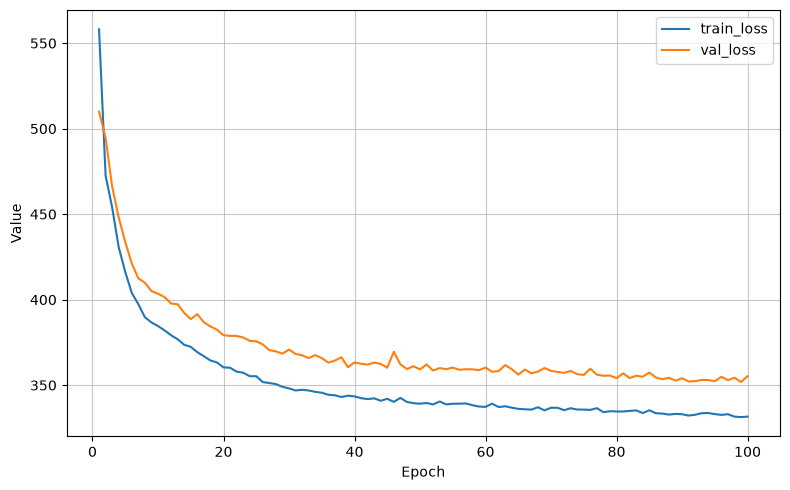

In [12]:
model = VAE().to(DEVICE)
optimizer = optim.Adam(model.parameters())

history = {"train_loss": [], "val_loss": []}

EPOCHS = 100
for epoch in range(EPOCHS):
    print(f"Epoch{epoch+1}----------------------------------------------")
    train_loss = train_vae(train_dataloader, model, optimizer, loss_fn, DEVICE)
    val_loss = test_vae(test_dataloader, model, loss_fn, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

plot_net(history)

In [ ]:
CLASS_LABELS = {i: str(i) for i in range(10)}


def extract_random_images(data_loader, num_images):
    all_images = []
    all_labels = []

    for images, labels in data_loader:
        all_images.append(images)
        all_labels.append(labels)

    all_images = torch.cat(all_images)
    all_labels = torch.cat(all_labels)

    indices = torch.randperm(len(all_images))[:num_images]

    return all_images[indices], all_labels[indices]


def display_images(images, labels, title, num_images_per_row=5):

    num_images = len(images)
    num_rows = (num_images + num_images_per_row - 1) // num_images_per_row

    fig, axes = plt.subplots(num_rows, num_images_per_row, figsize=(10, 2 * num_rows))

    # Make axes iterable even if there is only one row
    axes = axes.flatten()

    for i in range(num_images):
        # squeeze() is used in PyTorch to remove dimensions whose size is 1.
        # This is particularly useful with FashionMNIST, because each grayscale image has one color channel
        image = images[i].detach().cpu().squeeze()

        axes[i].imshow(image, cmap="gray")
        if labels is not None:
            axes[i].set_title(CLASS_LABELS[labels[i].item()])
        axes[i].axis("off")

    # Hide unused spaces
    for i in range(num_images, len(axes)):
        axes[i].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def display_random_images(
    data_loader,
    vae_model,
    title_recon=None,
    title_real=None,
    display_real=True,
    num_images=32,
    num_images_per_row=8,
):
    # extract a random subset of images and labels from the data loader
    random_images, random_labels = extract_random_images(data_loader, num_images)

    # if an encoder and decoder are provided,
    # use them to generate reconstructions
    if vae_model is not None:
        # set the encoder and decoder to evaluation mode
        vae_model.eval()
        random_images = random_images.to(DEVICE)

        random_reconstructions, _, _ = vae_model(random_images)

        display_images(
            random_reconstructions.cpu(),
            random_labels,
            title_recon,
            num_images_per_row,
        )

        if display_real:
            display_images(
                random_images.cpu(),
                random_labels,
                title_real,
                num_images_per_row,
            )

    # if no encoder and decoder are provided, simply display the original images
    else:
        display_images(random_images, random_labels, "Real Images", num_images_per_row)

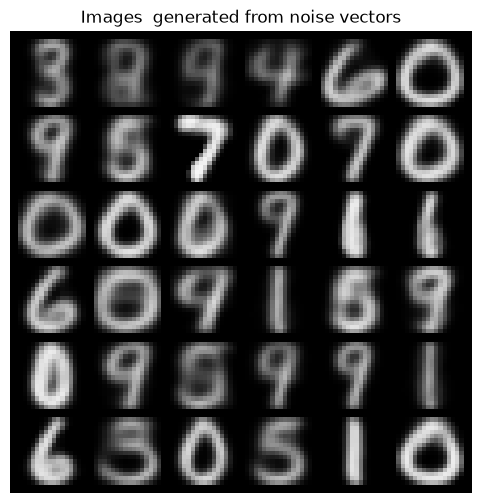

In [ ]:
with torch.no_grad():
    noise_vecs = torch.randn(36, 30)
    sampled = model.cpu().decoder(noise_vecs)
    gen_imgs = make_grid(sampled.reshape(36, 1, 16, 16), nrow=6).permute(1, 2, 0)

plt.figure(figsize=(6, 6))
plt.imshow(gen_imgs, cmap="gray")
plt.title("Images  generated from noise vectors")
plt.axis(False)
plt.show()

## Convolutional VAE


In [25]:
from torchvision.datasets import FashionMNIST

cwd = os.getcwd()
os.chdir("..")

transform = v2.Compose([v2.Pad(2), v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

train_data = FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)
test_data = FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

os.chdir(cwd)
os.getcwd()

'c:\\Users\\USER\\ipnyb files\\Autoencoders'

In [26]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

In [ ]:
class VAE_conv(nn.Module):

    def __init__(self, image_size, channels, embedding_dim):
        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------

        self.encoder = nn.Sequential(
            OrderedDict(
                [
                    ("conv1", nn.Conv2d(channels, 32, 3, 2, 1)),
                    ("relu1", nn.ReLU()),
                    ("conv2", nn.Conv2d(32, 64, 3, 2, 1)),
                    ("relu2", nn.ReLU()),
                    ("conv3", nn.Conv2d(64, 128, 3, 2, 1)),
                    ("relu3", nn.ReLU()),
                    ("flatten", nn.Flatten()),
                ]
            )
        )

        # Find the size of the encoder output automatically
        with torch.no_grad():
            dummy = torch.zeros(1, channels, image_size, image_size)

            feature_map = self.encoder[:-1](dummy)
            feature_shape = feature_map.shape[1:]
            flattened_size = feature_map.flatten(1).shape[1]

        # Convert CNN features → embedding
        self.fc = nn.Linear(flattened_size, embedding_dim)

        # Mean and log variance
        self._mu = nn.Linear(embedding_dim, embedding_dim)

        self._logvar = nn.Linear(embedding_dim, embedding_dim)

        # -------------------------
        # Decoder
        # -------------------------

        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, flattened_size),
            nn.Unflatten(1, feature_shape),
            nn.ConvTranspose2d(
                128, 128, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                128, 64, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                64, 32, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 16, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, channels, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

    def reparametrization(self, mu, logvar):

        std = torch.exp(0.5 * logvar)

        eps = torch.randn_like(std)

        z = mu + std * eps

        return z

    def forward(self, x):

        x = self.encoder(x)
        x = self.fc(x)

        # Latent distribution parameters
        mu = self._mu(x)
        logvar = self._logvar(x)
        z = self.reparametrization(mu, logvar)

        reconstruction = self.decoder(z)

        return reconstruction, mu, logvar

In [46]:
model = VAE_conv(image_size=28, channels=1, embedding_dim=4).to(DEVICE)
summary(model, input_size=(64, 1, 28, 28), device=DEVICE)

Layer (type:depth-idx)                   Output Shape              Param #
VAE_conv                                 [64, 1, 32, 32]           --
├─Sequential: 1-1                        [64, 2048]                --
│    └─Conv2d: 2-1                       [64, 32, 14, 14]          320
│    └─ReLU: 2-2                         [64, 32, 14, 14]          --
│    └─Conv2d: 2-3                       [64, 64, 7, 7]            18,496
│    └─ReLU: 2-4                         [64, 64, 7, 7]            --
│    └─Conv2d: 2-5                       [64, 128, 4, 4]           73,856
│    └─ReLU: 2-6                         [64, 128, 4, 4]           --
│    └─Flatten: 2-7                      [64, 2048]                --
├─Linear: 1-2                            [64, 4]                   8,196
├─Linear: 1-3                            [64, 4]                   20
├─Linear: 1-4                            [64, 4]                   20
├─Sequential: 1-5                        [64, 1, 32, 32]           --
│  

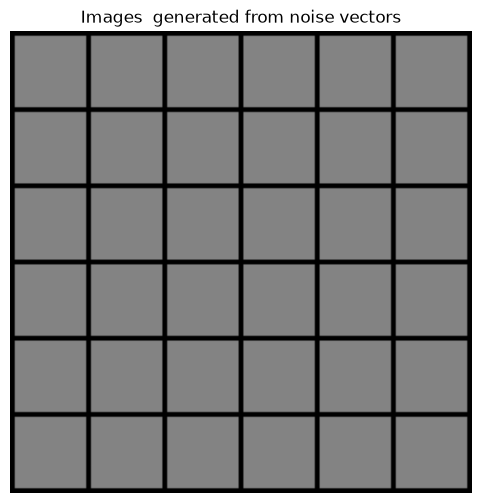

In [47]:
def loss_fn_conv(recon, x, mu, logvar):
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum")
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss


def train_conv_vae(dataloader, model, optimizer, loss_fn, device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()
        X, y = X.to(device), y.to(device)

        recon, mu, logvar = model(X)
        loss = loss_fn(recon, X, mu, logvar)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            print(f"Loss : {loss.item():>7f} [{(batch+1)*len(X):>5d} / {size}]")
    if batch % 100 != 0:
        print(f"Loss : {loss.item():>7f} [{(batch+1)*len(X):>5d} / {size:>5d}]")

    return train_loss / num_batches


def test_conv_vae(dataloader, model, loss_fn, device):
    num_batches = len(dataloader)

    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            recon, mu, logvar = model(X)
            loss = loss_fn(recon, X, mu, logvar)
            test_loss += loss.item()

    test_loss /= num_batches

    print(f"Test Error :\n Avg Loss : {test_loss:>7f} | \n")

    return test_loss


def plot_net(data_dict):
    plt.figure(figsize=(8, 5))

    for label, values in data_dict.items():
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=label)

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

Epoch1----------------------------------------------
Loss : 43755.613281 [   64 / 60000]
Loss : 21983.775391 [ 6464 / 60000]
Loss : 19303.828125 [12864 / 60000]
Loss : 18433.208984 [19264 / 60000]
Loss : 19019.140625 [25664 / 60000]
Loss : 16655.173828 [32064 / 60000]
Loss : 17082.462891 [38464 / 60000]
Loss : 16582.570312 [44864 / 60000]
Loss : 16313.769531 [51264 / 60000]
Loss : 17108.207031 [57664 / 60000]
Loss : 8202.051758 [30016 / 60000]
Test Error :
 Avg Loss : 16670.969342 | 

Epoch2----------------------------------------------
Loss : 17618.552734 [   64 / 60000]
Loss : 16551.509766 [ 6464 / 60000]
Loss : 16149.068359 [12864 / 60000]
Loss : 16171.676758 [19264 / 60000]
Loss : 16256.003906 [25664 / 60000]
Loss : 16613.720703 [32064 / 60000]
Loss : 15746.125000 [38464 / 60000]
Loss : 16458.330078 [44864 / 60000]
Loss : 17095.615234 [51264 / 60000]
Loss : 15649.550781 [57664 / 60000]
Loss : 8797.270508 [30016 / 60000]
Test Error :
 Avg Loss : 16461.276845 | 

Epoch3--------------

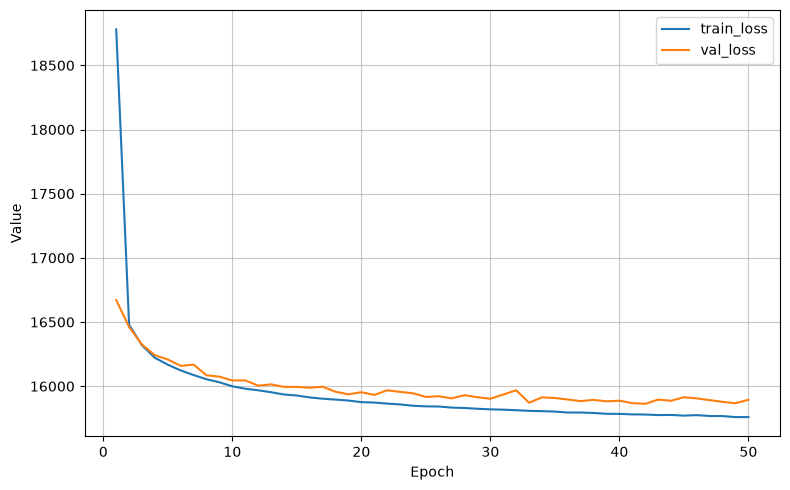

In [ ]:
model = VAE_conv(image_size=28, channels=1, embedding_dim=4).to(DEVICE)
optimizer = optim.Adam(model.parameters())

history = {"train_loss": [], "val_loss": []}

EPOCHS = 50
for epoch in range(EPOCHS):
    print(f"Epoch{epoch+1}----------------------------------------------")
    train_loss = train_conv_vae(
        train_dataloader, model, optimizer, loss_fn_conv, DEVICE
    )
    val_loss = test_conv_vae(test_dataloader, model, loss_fn_conv, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

plot_net(history)

In [49]:
for batch, (X, y) in enumerate(train_dataloader):
    print(X.shape)
    break

torch.Size([64, 1, 32, 32])


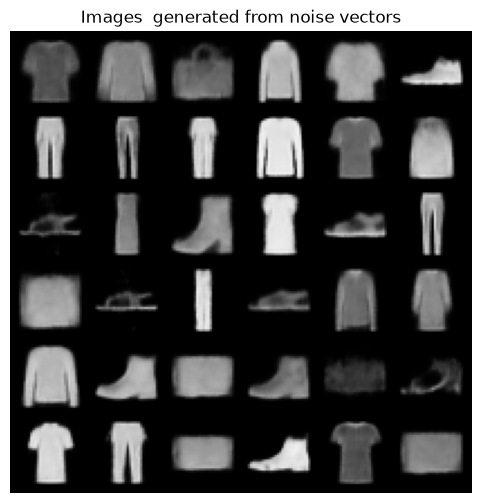

In [50]:
with torch.no_grad():
    noise_vecs = torch.randn(36, 4)
    sampled = model.cpu().decoder(noise_vecs)
    gen_imgs = make_grid(sampled, nrow=6).permute(1, 2, 0)

plt.figure(figsize=(6, 6))
plt.imshow(gen_imgs, cmap="gray")
plt.title("Images  generated from noise vectors")
plt.axis(False)
plt.show()

## Experiment


In [ ]:
import torch


def loss_fn_conv_aggregate(recon, x, mu, logvar):
    """
    VAE loss using the aggregate latent distribution.

    Reconstruction:
        MSE(recon, x)

    Regularization:
        KL(q_aggregate(z) || N(0, I))

    q_aggregate(z) is approximated as a diagonal Gaussian
    using the mean and variance of the encoder posteriors
    across the batch.
    """

    # -------------------------
    # 1. Reconstruction loss
    # -------------------------
    recon_loss = F.binary_cross_entropy(recon, x, reduction="sum")

    # -------------------------
    # 2. Aggregate posterior
    # -------------------------

    # E[z]
    aggregate_mu = mu.mean(dim=0)

    # E[z^2]
    # Since:
    # E[z^2] = variance + mean^2
    expected_z2 = (logvar.exp() + mu.pow(2)).mean(dim=0)

    # Var[z] = E[z^2] - E[z]^2
    aggregate_var = expected_z2 - aggregate_mu.pow(2)

    # Numerical safety
    aggregate_var = torch.clamp(aggregate_var, min=1e-8)

    aggregate_logvar = torch.log(aggregate_var)

    # -------------------------
    # 3. KL(q_aggregate || N(0,I))
    # -------------------------
    kl_loss = -0.5 * torch.sum(
        1 + aggregate_logvar - aggregate_mu.pow(2) - aggregate_var
    )

    # -------------------------
    # 4. Total loss
    # -------------------------
    total_loss = recon_loss + kl_loss

    return total_loss

Epoch1----------------------------------------------
Loss : 45692.804688 [   64 / 60000]
Loss : 23368.396484 [ 6464 / 60000]
Loss : 17240.080078 [12864 / 60000]
Loss : 17845.066406 [19264 / 60000]
Loss : 16557.642578 [25664 / 60000]
Loss : 16199.473633 [32064 / 60000]
Loss : 16543.974609 [38464 / 60000]
Loss : 16015.282227 [44864 / 60000]
Loss : 16414.677734 [51264 / 60000]
Loss : 15527.401367 [57664 / 60000]
Loss : 8176.121094 [30016 / 60000]
Test Error :
 Avg Loss : 16137.104377 | 

Epoch2----------------------------------------------
Loss : 17472.882812 [   64 / 60000]
Loss : 16430.035156 [ 6464 / 60000]
Loss : 17369.519531 [12864 / 60000]
Loss : 14840.679688 [19264 / 60000]
Loss : 15737.858398 [25664 / 60000]
Loss : 16252.537109 [32064 / 60000]
Loss : 15952.379883 [38464 / 60000]
Loss : 16518.265625 [44864 / 60000]
Loss : 16612.550781 [51264 / 60000]
Loss : 15739.074219 [57664 / 60000]
Loss : 8468.847656 [30016 / 60000]
Test Error :
 Avg Loss : 15652.013446 | 

Epoch3--------------

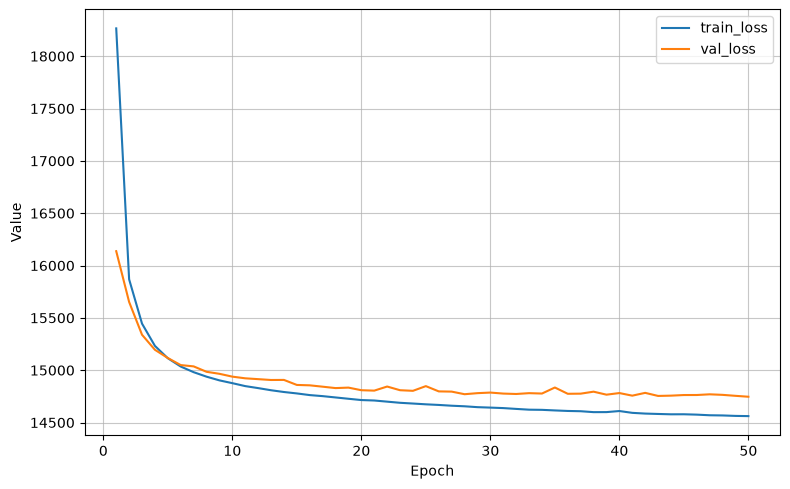

In [52]:
model = VAE_conv(image_size=28, channels=1, embedding_dim=4).to(DEVICE)
optimizer = optim.Adam(model.parameters())

history = {"train_loss": [], "val_loss": []}

EPOCHS = 50
for epoch in range(EPOCHS):
    print(f"Epoch{epoch+1}----------------------------------------------")
    train_loss = train_conv_vae(
        train_dataloader, model, optimizer, loss_fn_conv_aggregate, DEVICE
    )
    val_loss = test_conv_vae(test_dataloader, model, loss_fn_conv_aggregate, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

plot_net(history)

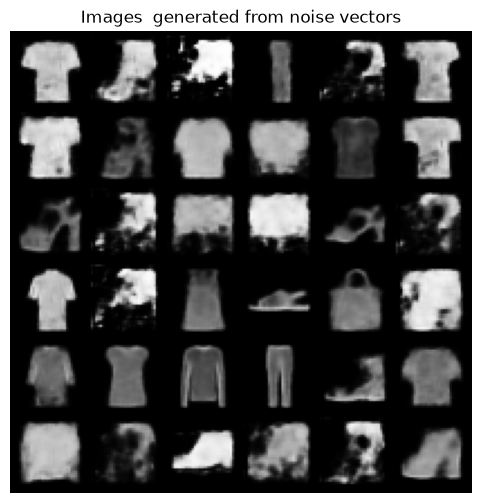

In [53]:
with torch.no_grad():
    noise_vecs = torch.randn(36, 4)
    sampled = model.cpu().decoder(noise_vecs)
    gen_imgs = make_grid(sampled, nrow=6).permute(1, 2, 0)

plt.figure(figsize=(6, 6))
plt.imshow(gen_imgs, cmap="gray")
plt.title("Images  generated from noise vectors")
plt.axis(False)
plt.show()

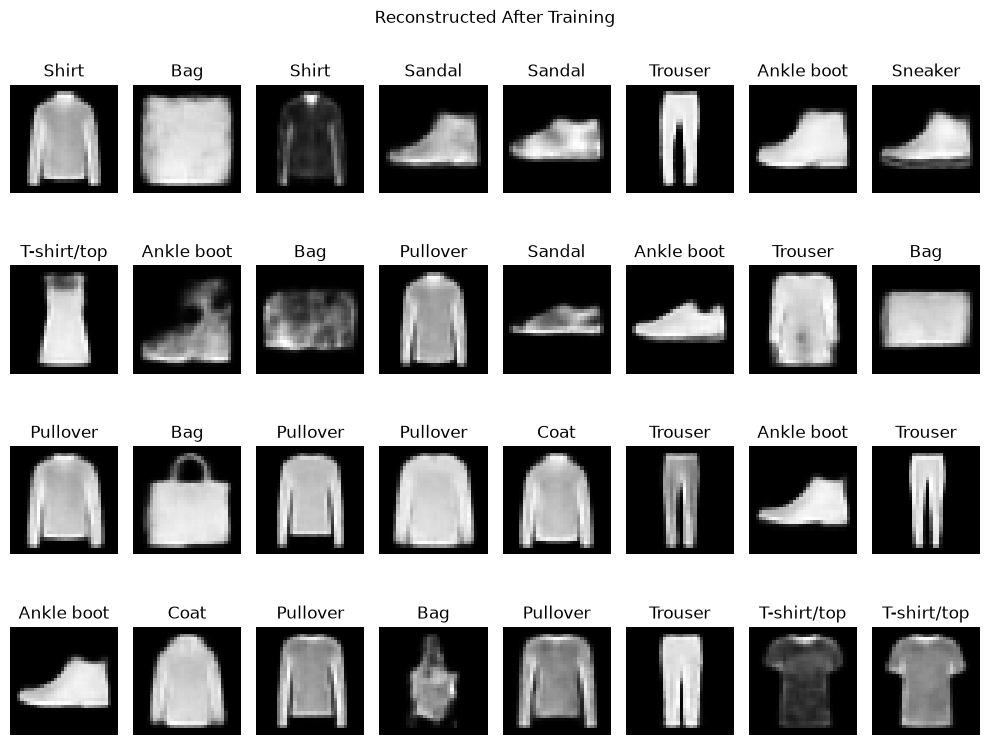

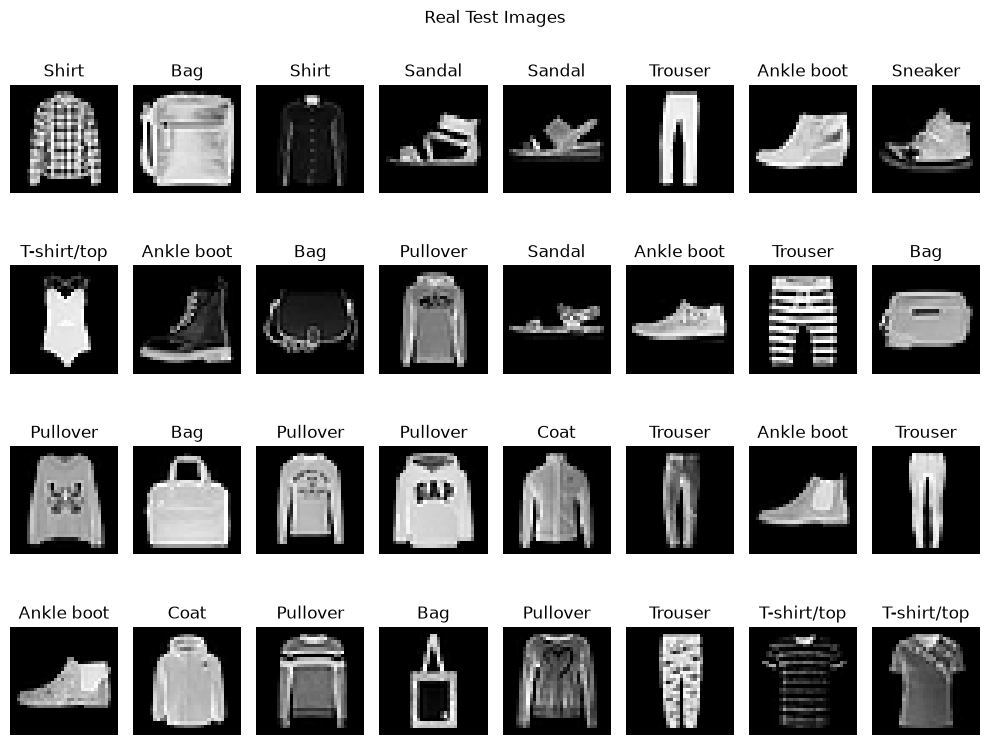

In [57]:
CLASS_LABELS = {k: v for k, v in (enumerate(train_data.classes))}

display_random_images(
    test_dataloader,
    model.to(DEVICE),
    title_recon="Reconstructed After Training",
    title_real="Real Test Images",
)

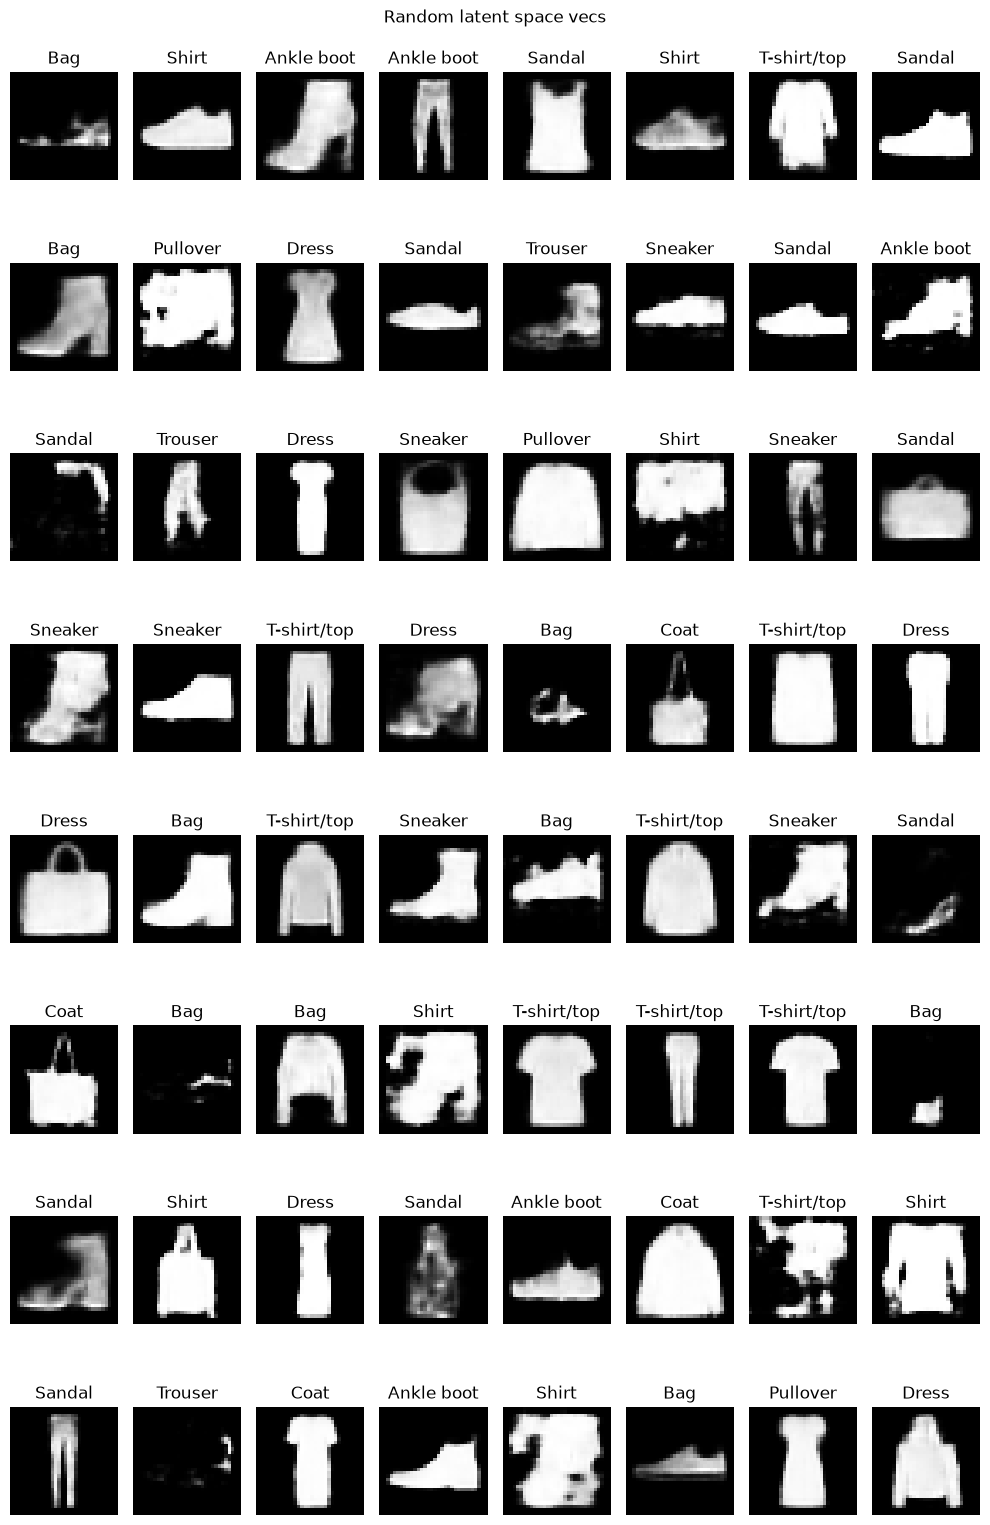

In [58]:
model.eval()

with torch.no_grad():

    for x, y in train_dataloader:

        x = x.to(DEVICE)

        features = model.encoder(x)
        features = model.fc(features)

        mu = model._mu(features)
        logvar = model._logvar(features)

        # Sample from q(z|x)
        std = torch.exp(0.5 * logvar)
        embeddings = mu + std * torch.randn_like(std)

        # Add additional random perturbation
        random_noise = torch.randn_like(embeddings)
        random_embeddings = embeddings + 2 * random_noise

        # Decode
        generated_images = model.decoder(random_embeddings)

        break

display_images(generated_images.cpu(), y.cpu(), "Random latent space vecs", 8)